In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import pytz
import pmdarima as pm
from itertools import product
from functools import partial
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import norm
from sklearn.utils import resample
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from fit_sarimax import *

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
sales = pd.read_csv('pedidos-1743765883268.csv', sep=';', encoding='latin1')

In [3]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [4]:
pd.to_datetime('2025-03-31 00:00:00')

Timestamp('2025-03-31 00:00:00')

In [5]:
SAO_PAULO_TZ = pytz.timezone('America/Sao_Paulo')
LOOKBACK = 1
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
START_DATE = END_DATE - timedelta(hours=23)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
# OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
# OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
# oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
# df_oot = pd.DataFrame(index=oot_dates)

In [9]:
df.drop('count', axis=1, inplace=True)
for account_id in df['account_id'].unique():
    df = pd.concat([df, pd.DataFrame({'account_id': [account_id], 'sales_channel_id': ['ALL']})], ignore_index=True)

In [10]:
df[df['account_id'] == 'b8c6ac4b-2999-40f4-ad33-17649fb2f0aa']

,account_id,sales_channel_id
37,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,1
70,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,17
89,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,4
119,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,2
124,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,13
125,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,14
127,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,6
134,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,5
144,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,19
162,b8c6ac4b-2999-40f4-ad33-17649fb2f0aa,15


In [11]:
account_ids = ['f9129295-bb08-4330-b60c-9f0beadda521', '05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6', '9d39683a-47b3-4a18-942d-f1d741a47e8c']

df_filtered = df[df['account_id'].isin(account_ids)]

In [12]:
df_filtered

,account_id,sales_channel_id
1,9d39683a-47b3-4a18-942d-f1d741a47e8c,1
2,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,3
5,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,6
7,f9129295-bb08-4330-b60c-9f0beadda521,1
11,f9129295-bb08-4330-b60c-9f0beadda521,2
15,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,5
29,f9129295-bb08-4330-b60c-9f0beadda521,10
48,f9129295-bb08-4330-b60c-9f0beadda521,38
51,f9129295-bb08-4330-b60c-9f0beadda521,16
55,f9129295-bb08-4330-b60c-9f0beadda521,18


In [13]:
dbname = 'railway'
username = 'sinatra'
pwd = '781B3XjpeuqE'
hostname = 'monorail.proxy.rlwy.net'
port = 25096

connection = psycopg2.connect(database=dbname, user=username, password=pwd, host=hostname, port=port)
cursor = connection.cursor()

In [14]:
cursor.execute("select distinct account_id, channel from public.forecast where model='SARIMAX_10';")

In [15]:
res_forecast = cursor.fetchall()

In [16]:
res_forecast

[]

In [17]:
len(res_forecast)

0

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 1
price_total_agg
train RMSE: 19013.644
train MAE:  13547.587
test RMSE: 16796.031
test MAE:  13259.753


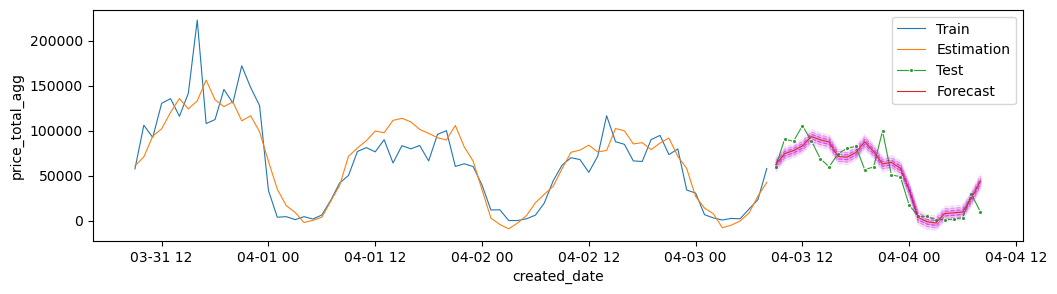

n_orders
train RMSE: 14.489
train MAE:  10.934
test RMSE: 17.950
test MAE:  12.571


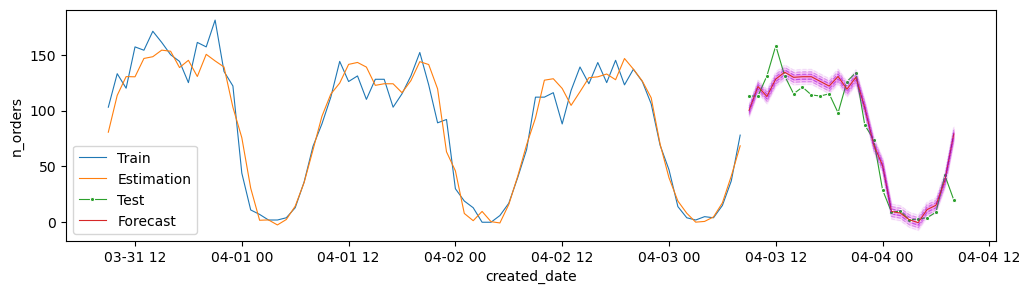

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 3
price_total_agg
train RMSE: 7976.503
train MAE:  4783.368
test RMSE: 5933.515
test MAE:  4678.496


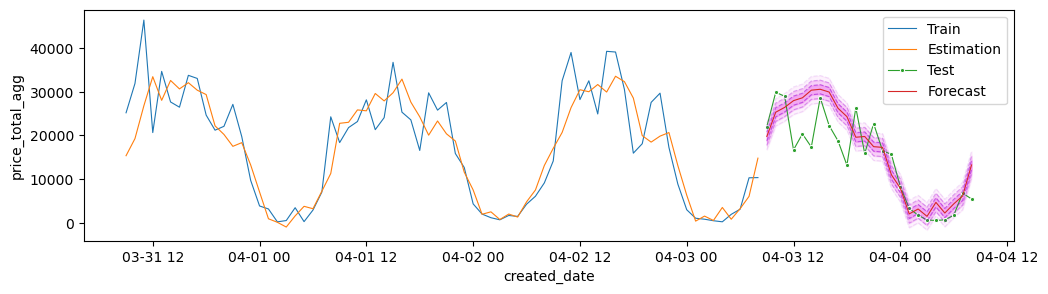

n_orders
train RMSE: 14.024
train MAE:  9.745
test RMSE: 16.437
test MAE:  10.677


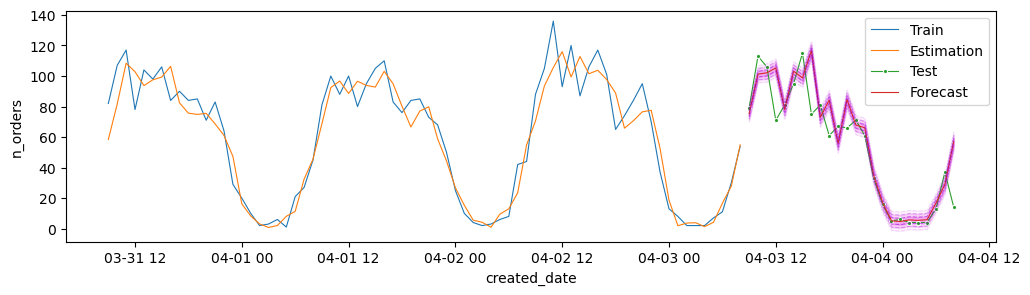

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 6
price_total_agg
train RMSE: 4744.934
train MAE:  3175.868
test RMSE: 4515.212
test MAE:  3362.257


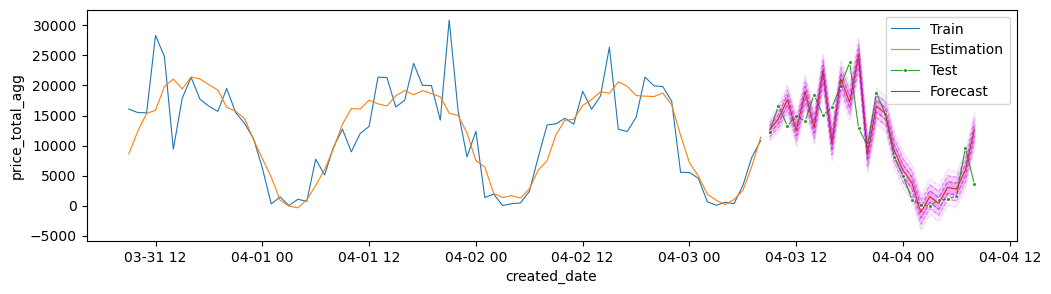

n_orders
train RMSE: 7.815
train MAE:  5.758
test RMSE: 9.006
test MAE:  7.234


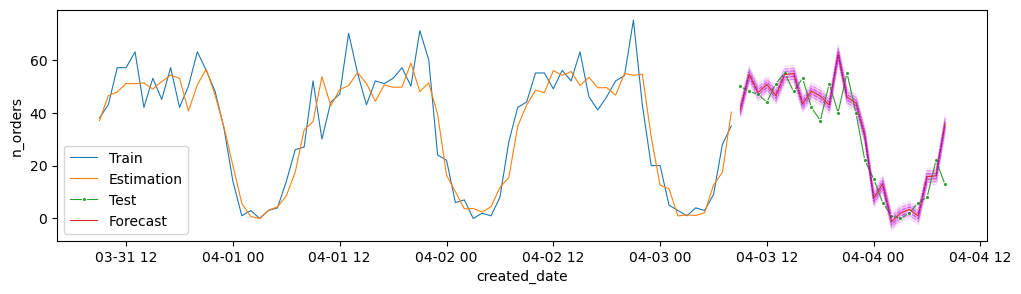

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 1
price_total_agg
train RMSE: 54250.944
train MAE:  36078.202
test RMSE: 41093.239
test MAE:  30096.726


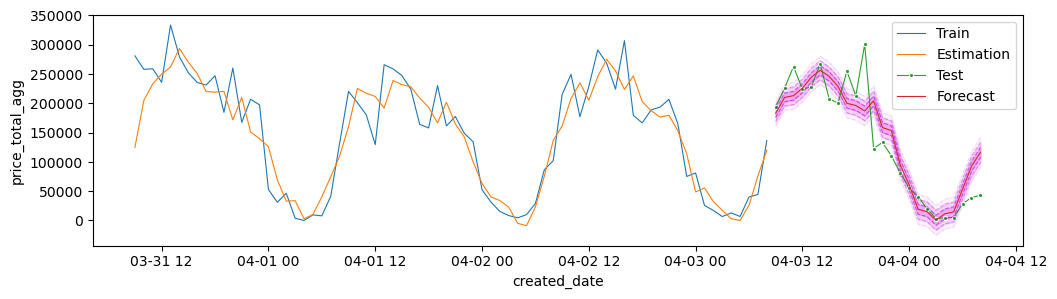

n_orders
train RMSE: 14.056
train MAE:  9.861
test RMSE: 12.665
test MAE:  9.639


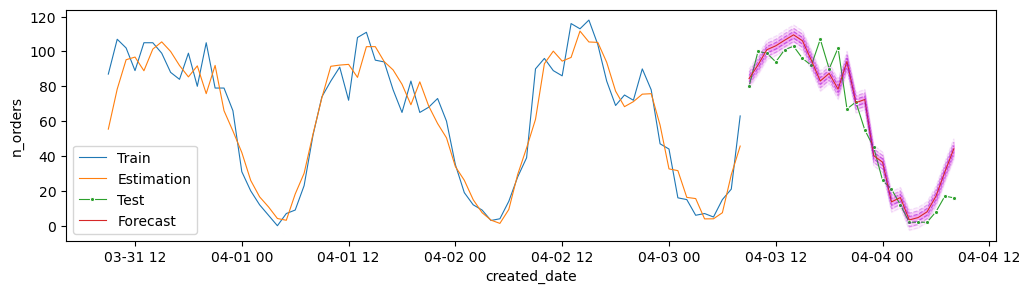

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 2
price_total_agg
train RMSE: 102327.054
train MAE:  68637.736
test RMSE: 113050.891
test MAE:  76160.815


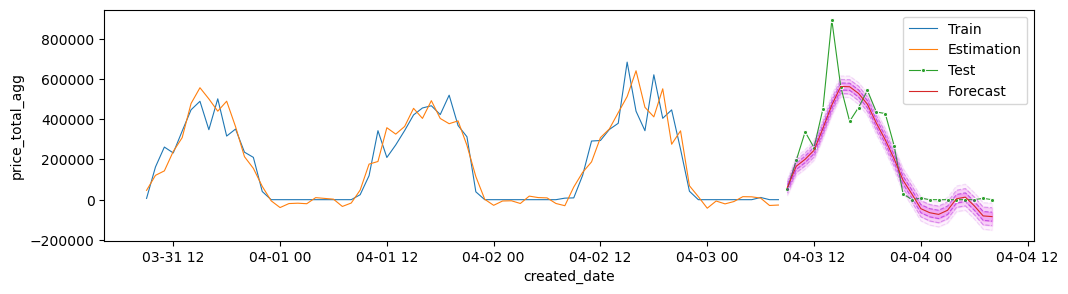

n_orders
train RMSE: 27.629
train MAE:  18.382
test RMSE: 16.285
test MAE:  11.807


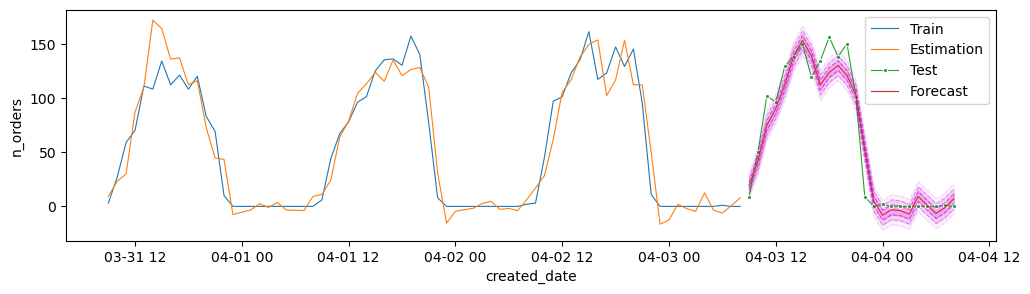

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 5
price_total_agg
train RMSE: 1455.281
train MAE:  773.524
test RMSE: 1102.816
test MAE:  814.407


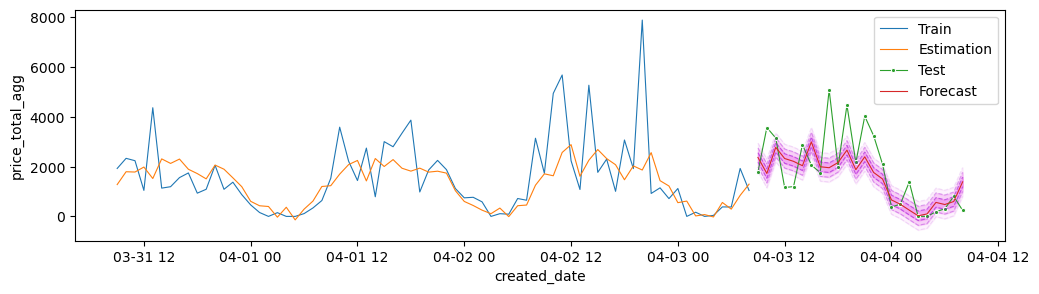

n_orders
train RMSE: 4.736
train MAE:  2.199
test RMSE: 4.305
test MAE:  3.013


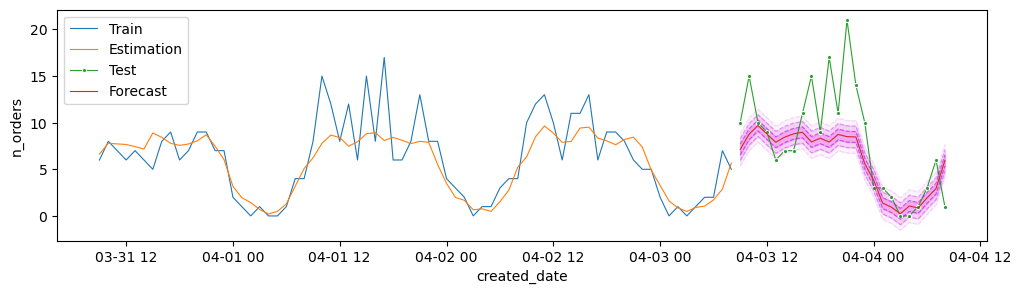

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 10
price_total_agg
train RMSE: 23870.653
train MAE:  11642.933
test RMSE: 42511.329
test MAE:  39522.505


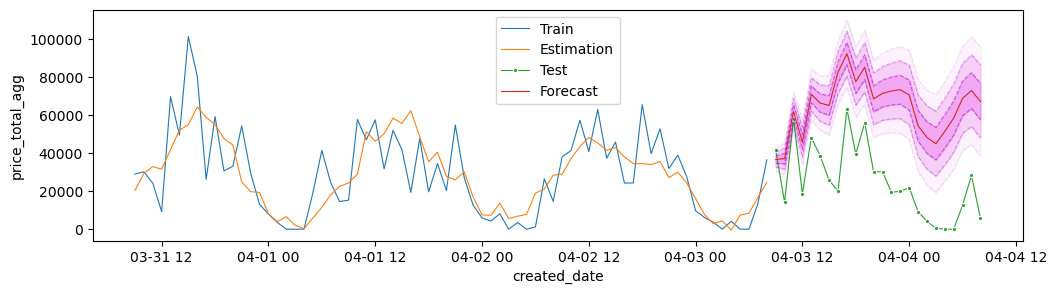

n_orders
train RMSE: 4.279
train MAE:  3.109
test RMSE: 4.691
test MAE:  3.659


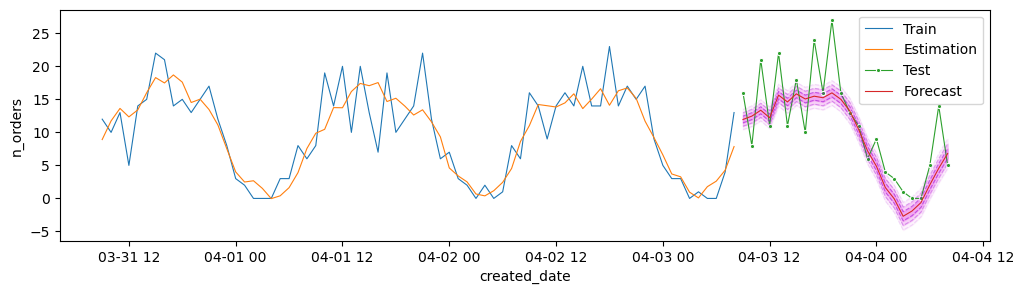

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 38
price_total_agg
train RMSE: 8940.840
train MAE:  6539.321
test RMSE: 12413.944
test MAE:  9125.809


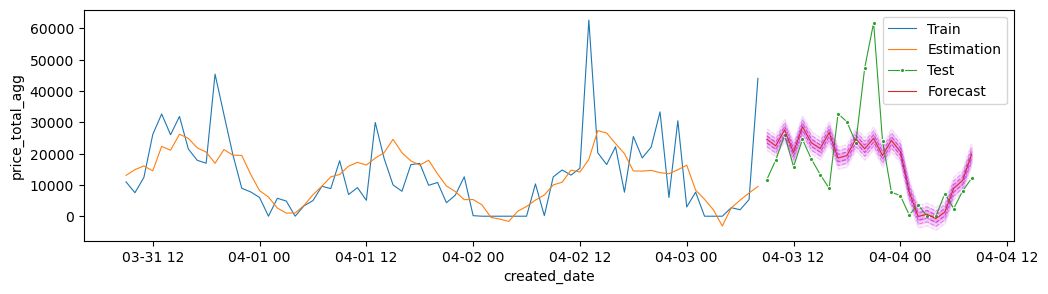

n_orders
train RMSE: 3.575
train MAE:  2.516
test RMSE: 3.479
test MAE:  2.294


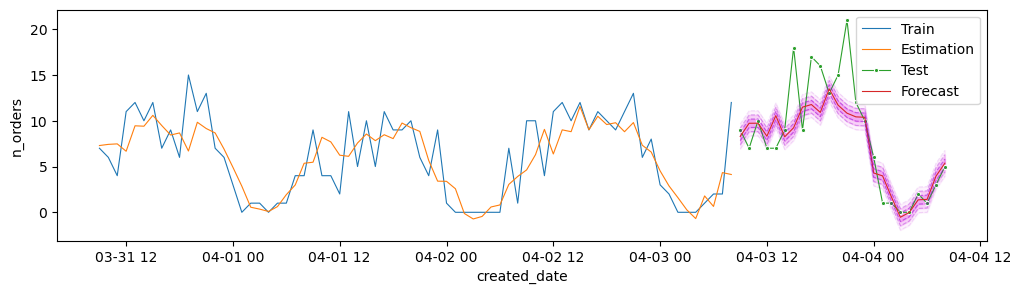

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 16
price_total_agg
train RMSE: 21406.051
train MAE:  14167.295
test RMSE: 16266.396
test MAE:  11997.963


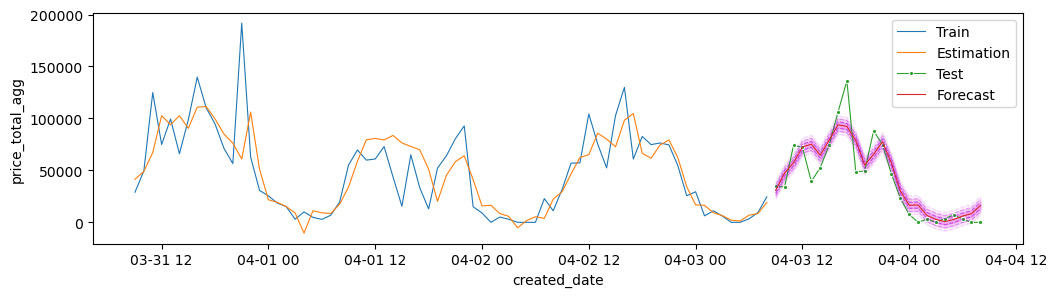

n_orders
train RMSE: 4.813
train MAE:  3.275
test RMSE: 4.633
test MAE:  3.362


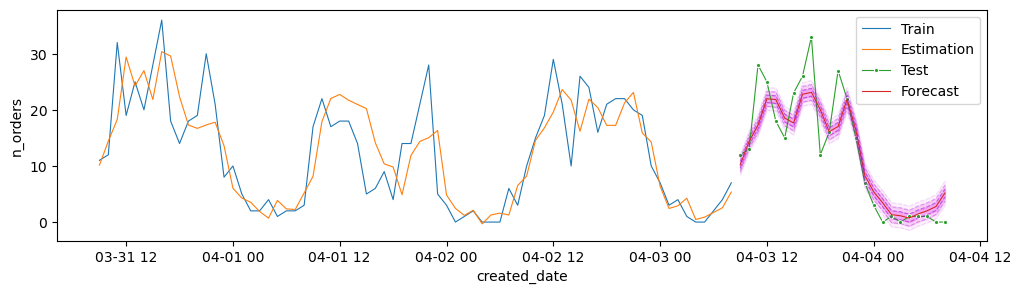

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 18
price_total_agg
train RMSE: 10125.288
train MAE:  7327.675
test RMSE: 12335.492
test MAE:  9734.937


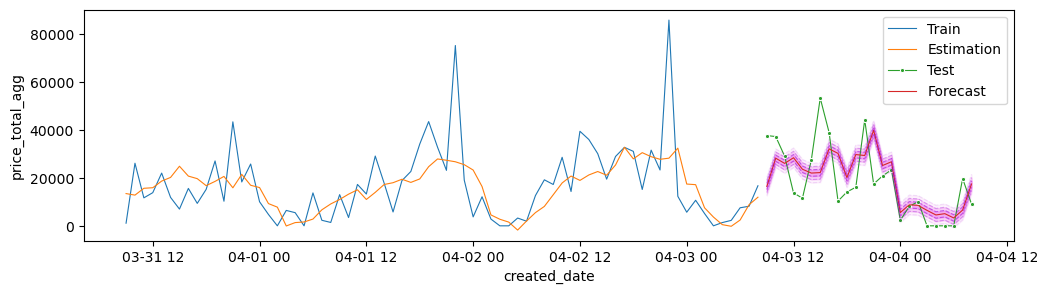

n_orders
train RMSE: 3.562
train MAE:  2.564
test RMSE: 5.511
test MAE:  4.258


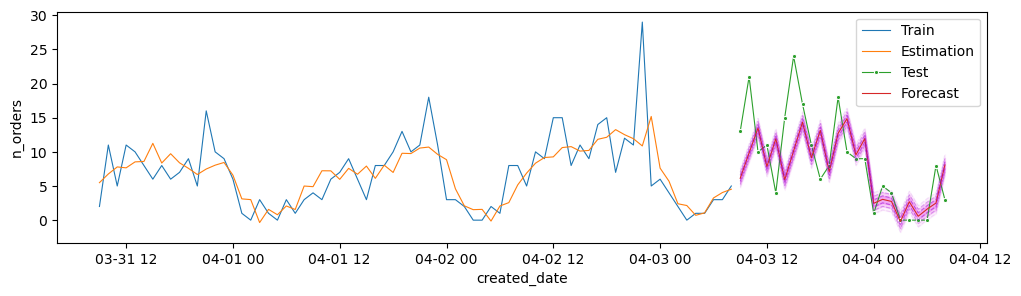

account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6
sales_channel_id: 1
price_total_agg
train RMSE: 5604.134
train MAE:  2401.081
test RMSE: 1741.463
test MAE:  1195.526


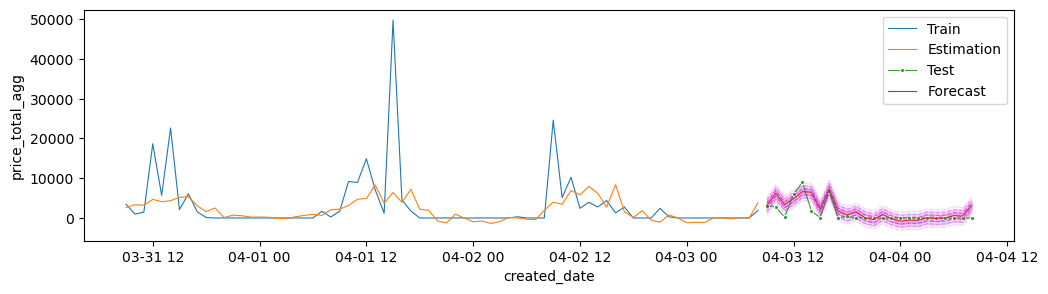

n_orders
train RMSE: 1.144
train MAE:  0.783
test RMSE: 1.665
test MAE:  1.223


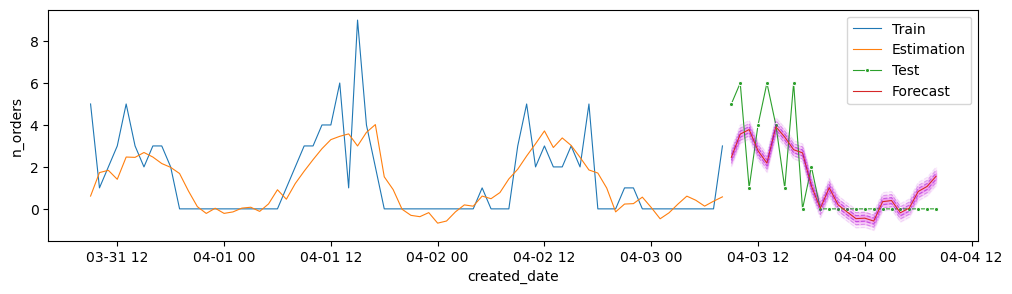

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 17
price_total_agg
train RMSE: 11296.272
train MAE:  8380.755
test RMSE: 14560.888
test MAE:  10309.943


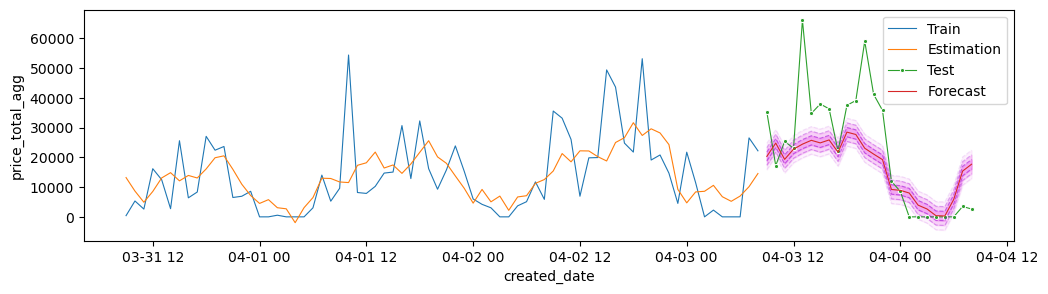

n_orders
train RMSE: 2.937
train MAE:  2.132
test RMSE: 3.859
test MAE:  2.678


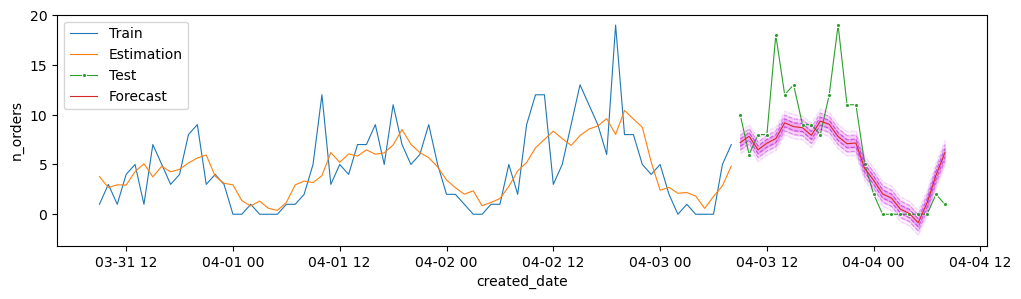

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 6
price_total_agg
train RMSE: 43186.613
train MAE:  10496.627
test RMSE: 10382.666
test MAE:  7453.725


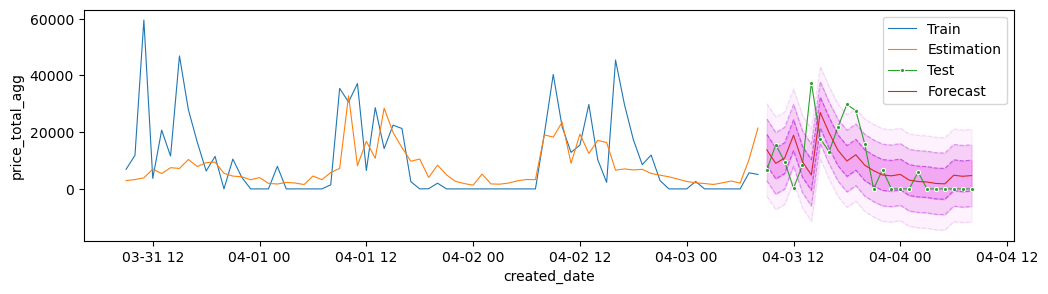

n_orders
train RMSE: 1.708
train MAE:  1.115
test RMSE: 1.723
test MAE:  1.348


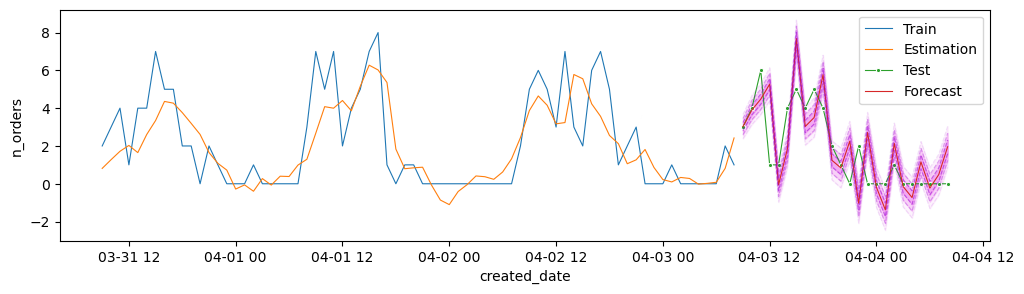

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 22
price_total_agg
train RMSE: 3300.260
train MAE:  1741.943
test RMSE: 2435.866
test MAE:  1471.043


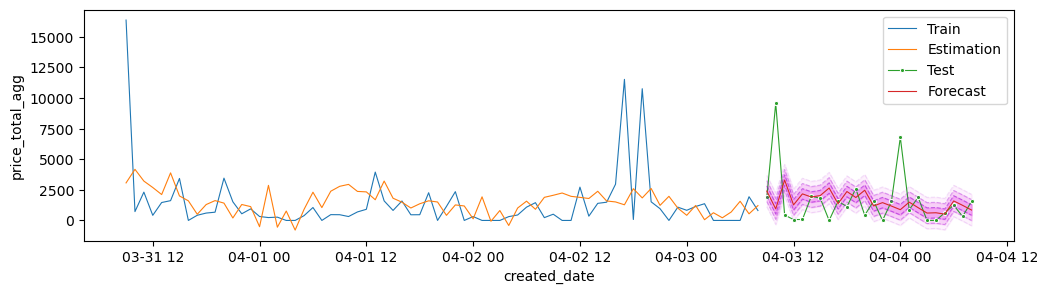

n_orders
train RMSE: 3.903
train MAE:  2.068
test RMSE: 3.578
test MAE:  2.067


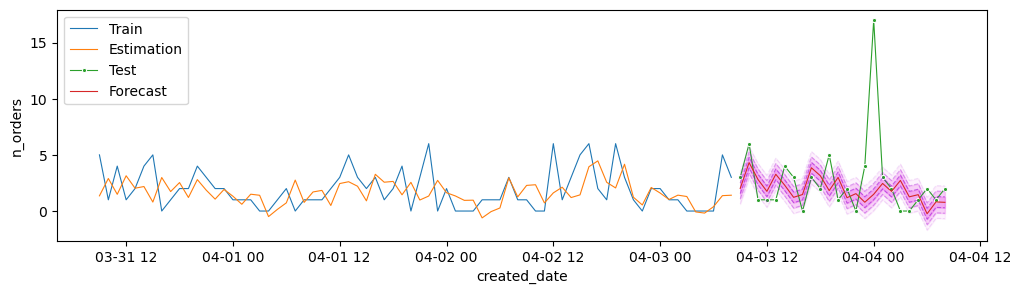

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 20
price_total_agg
train RMSE: 3203.364
train MAE:  2027.288
test RMSE: 11057.334
test MAE:  3835.517


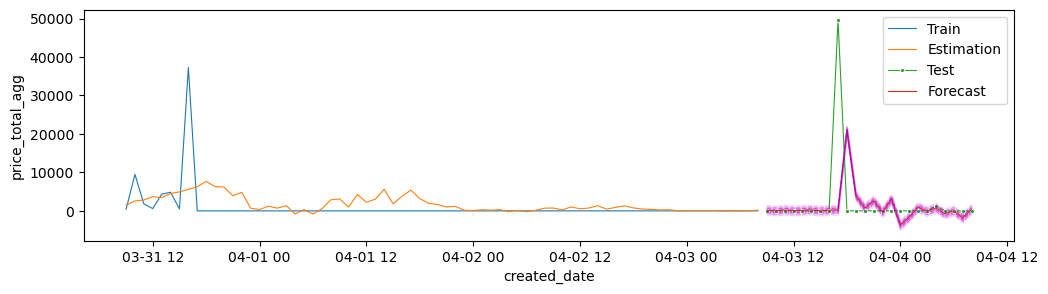

n_orders
train RMSE: 1.680
train MAE:  1.180
test RMSE: 6.200
test MAE:  2.216


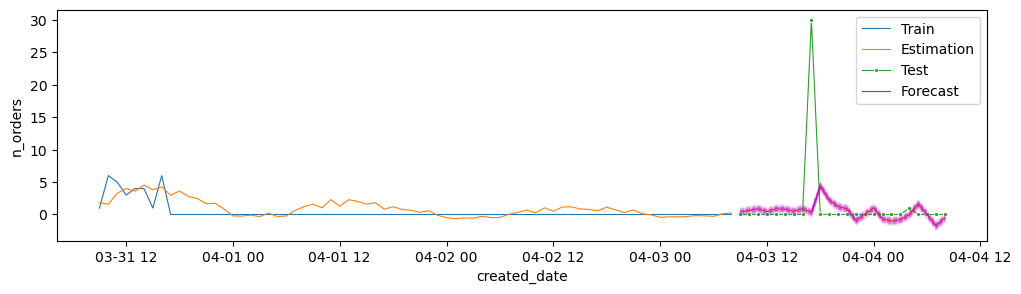

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 31
price_total_agg
train RMSE: 1725.733
train MAE:  1081.118
test RMSE: 1783.688
test MAE:  1248.317


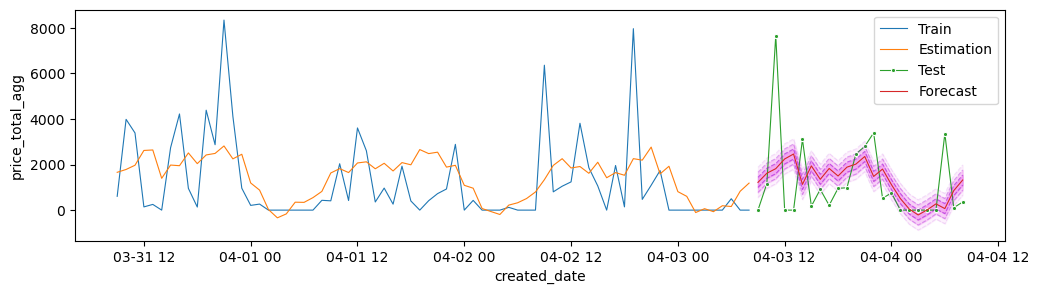

n_orders
train RMSE: 1.726
train MAE:  1.189
test RMSE: 1.359
test MAE:  1.116


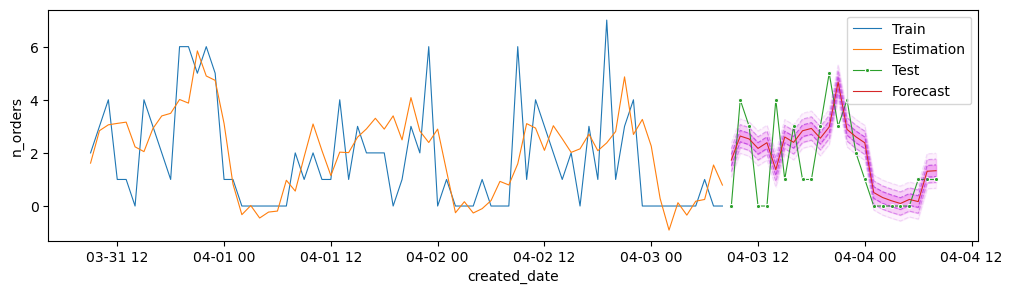

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 15
price_total_agg
train RMSE: 4387.923
train MAE:  3100.633
test RMSE: 8336.751
test MAE:  4696.666


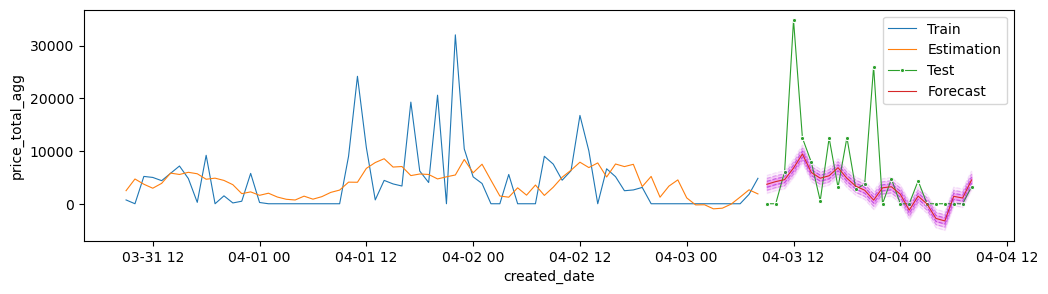

n_orders
train RMSE: 1.262
train MAE:  0.910
test RMSE: 2.814
test MAE:  1.532


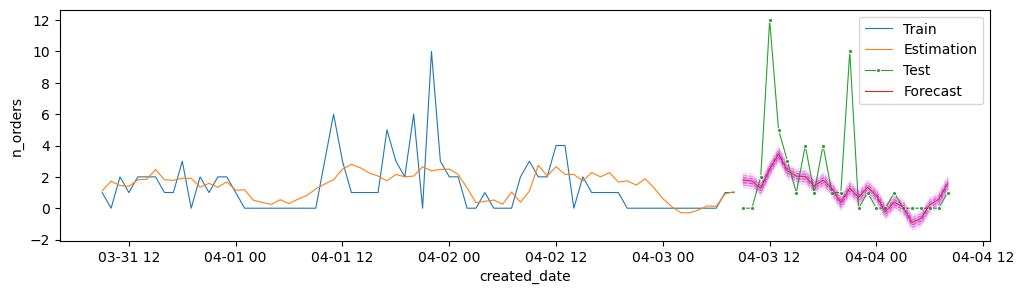

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 43
price_total_agg
train RMSE: 7071.586
train MAE:  4105.585
test RMSE: 11355.741
test MAE:  6398.483


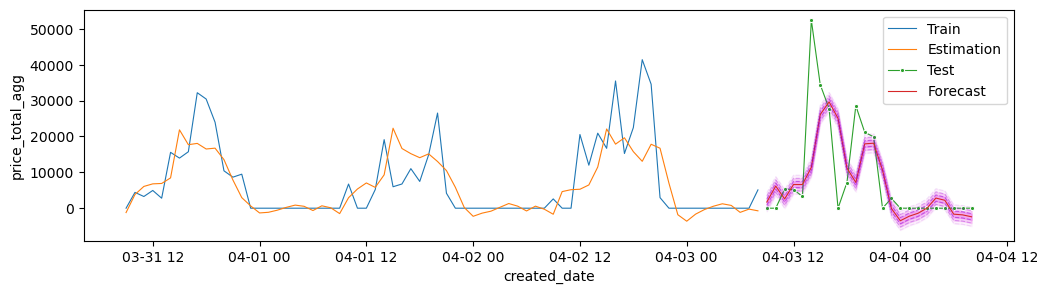

n_orders
train RMSE: 1.366
train MAE:  0.836
test RMSE: 1.875
test MAE:  1.199


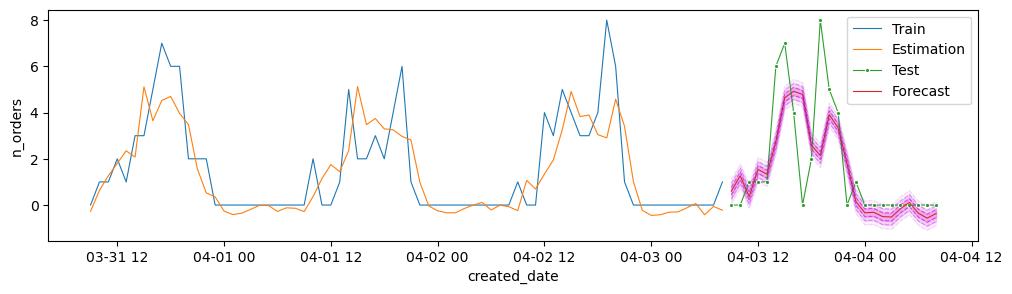

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 21
price_total_agg
train RMSE: 4398.873
train MAE:  3160.346
test RMSE: 4558.542
test MAE:  3304.604


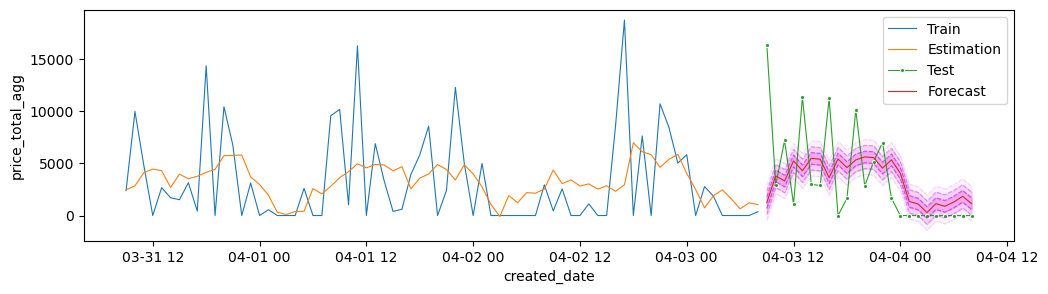

n_orders
train RMSE: 1.545
train MAE:  1.098
test RMSE: 1.549
test MAE:  1.166


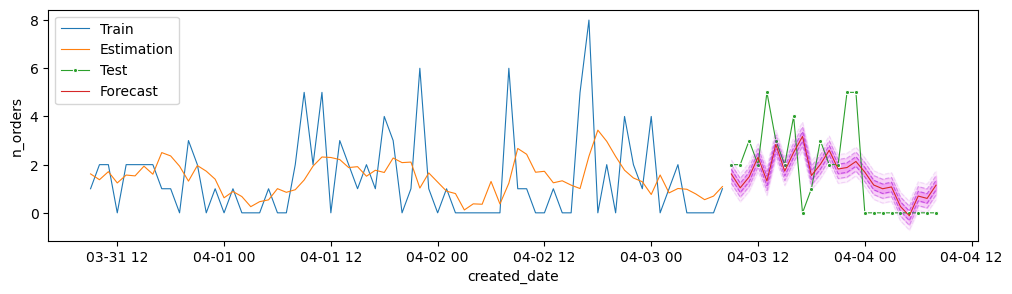

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 39
price_total_agg
train RMSE: 2170.202
train MAE:  1371.176
test RMSE: 1677.123
test MAE:  1318.525


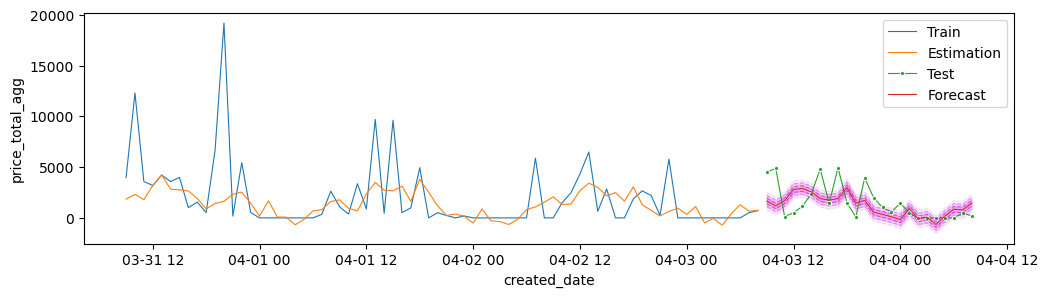

n_orders
train RMSE: 1.350
train MAE:  0.777
test RMSE: 0.805
test MAE:  0.639


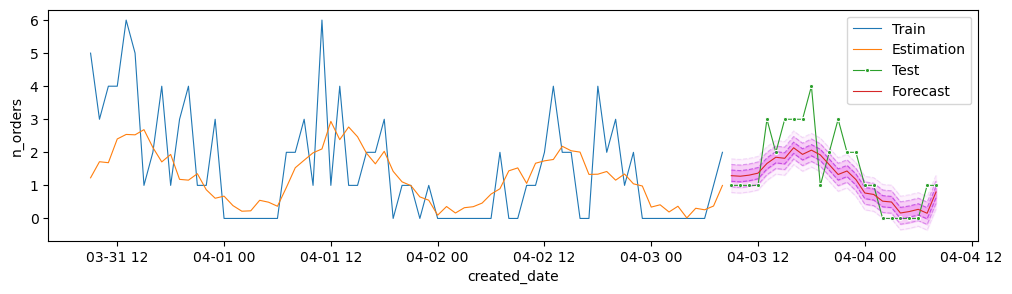

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 33
price_total_agg
train RMSE: 2236.430
train MAE:  1169.686
test RMSE: 1656.861
test MAE:  1418.312


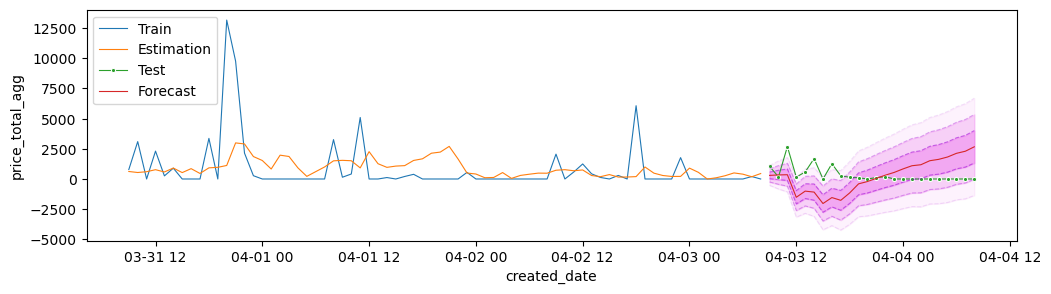

n_orders
train RMSE: 1.161
train MAE:  0.808
test RMSE: 0.619
test MAE:  0.457


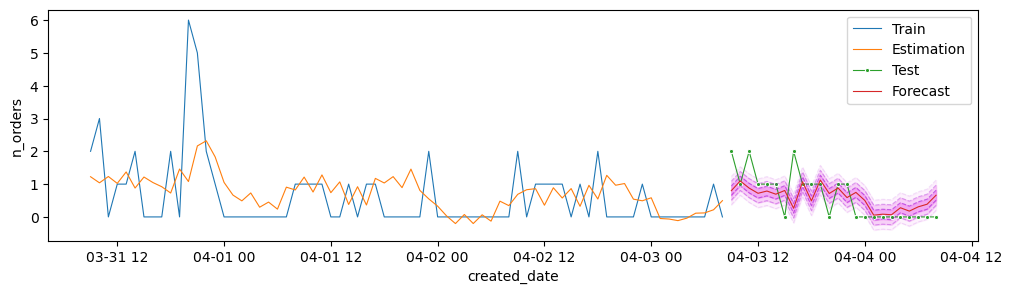

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 32
price_total_agg
train RMSE: 1132.238
train MAE:  644.604
test RMSE: 1284.280
test MAE:  789.161


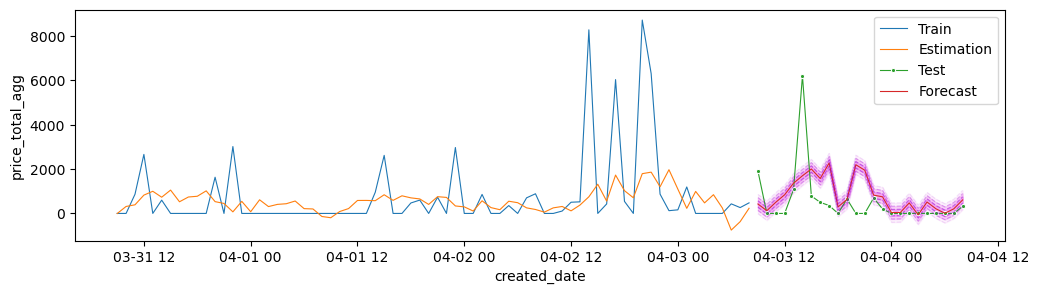

n_orders
train RMSE: 0.859
train MAE:  0.636
test RMSE: 0.693
test MAE:  0.553


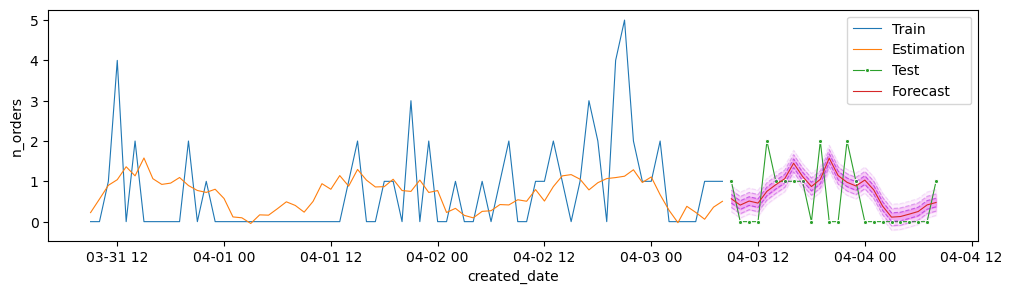

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 26
price_total_agg
train RMSE: 2243.748
train MAE:  1198.458
test RMSE: 4605.767
test MAE:  2804.412


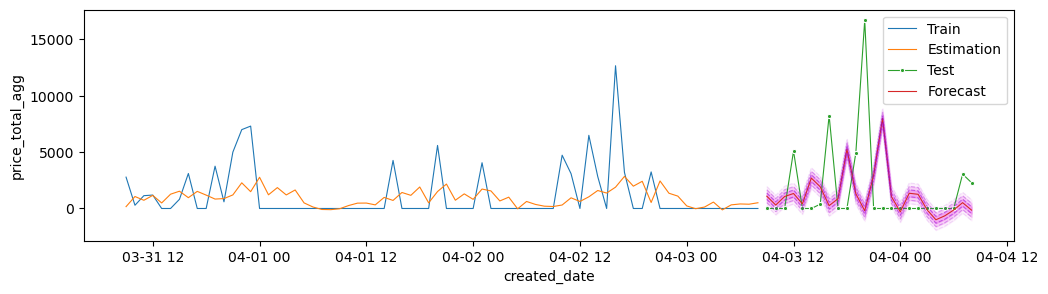

n_orders
train RMSE: 0.608
train MAE:  0.396
test RMSE: 0.669
test MAE:  0.514


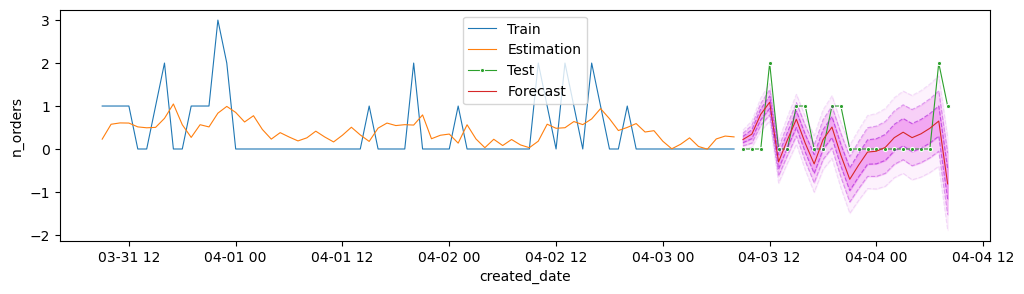

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 19
price_total_agg
train RMSE: 2226.431
train MAE:  1409.303
test RMSE: 2420.839
test MAE:  2223.025


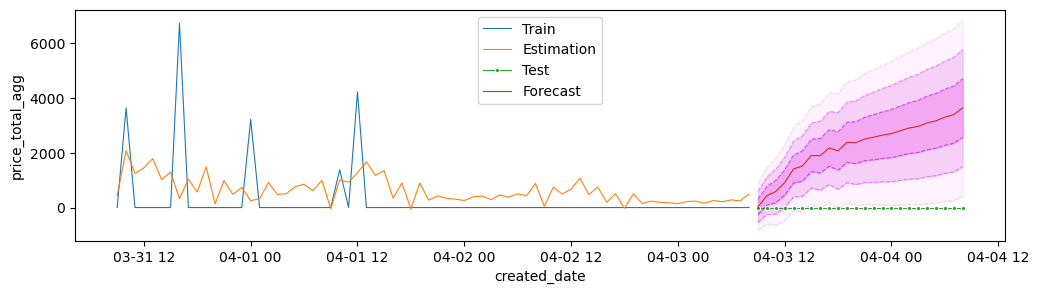

n_orders
train RMSE: 0.695
train MAE:  0.478
test RMSE: 1.330
test MAE:  1.231


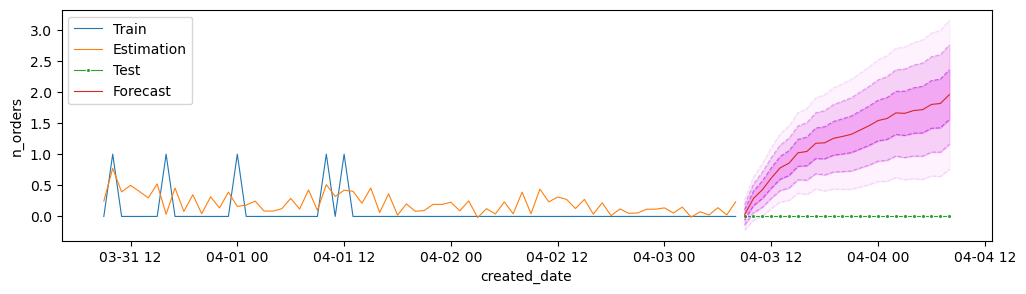

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 27
price_total_agg
train RMSE: 2998.968
train MAE:  1716.650
test RMSE: 17912.950
test MAE:  10317.353


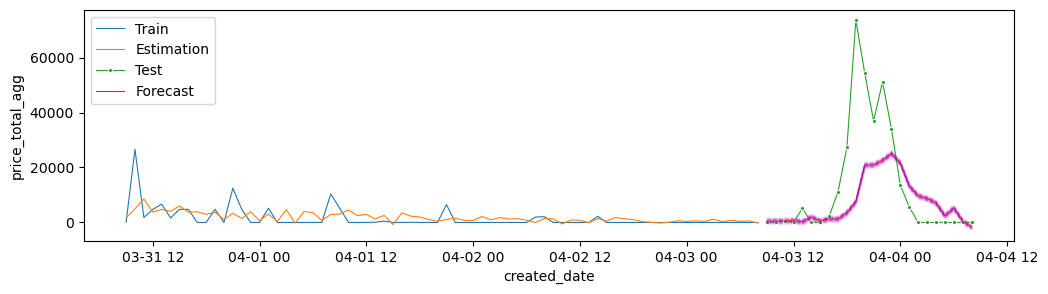

n_orders
train RMSE: 0.767
train MAE:  0.507
test RMSE: 5.711
test MAE:  3.515


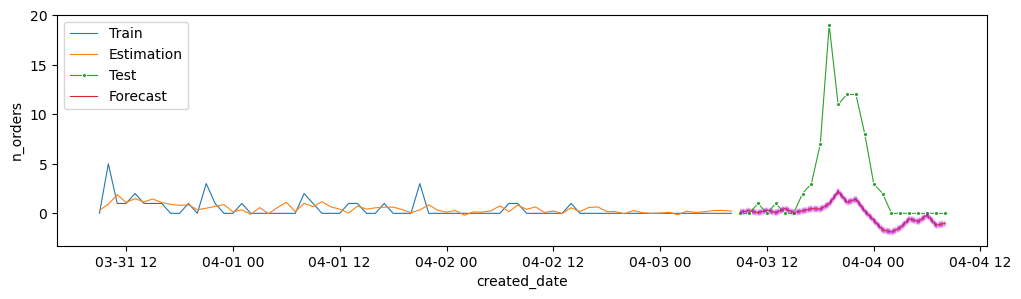

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 7
price_total_agg
train RMSE: 1272.682
train MAE:  540.806
test RMSE: 1094.107
test MAE:  487.962


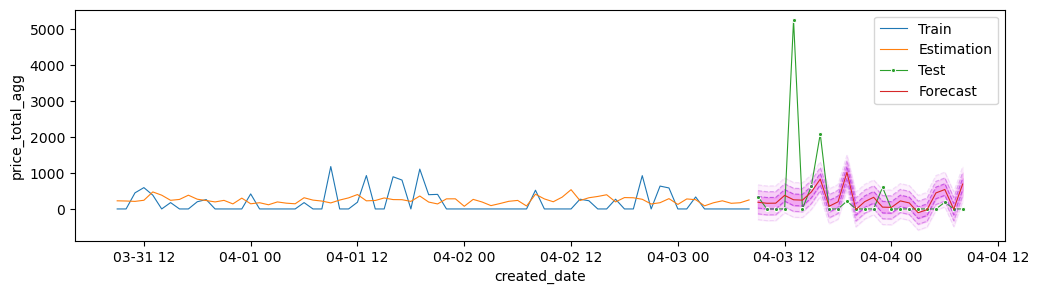

n_orders
train RMSE: 0.737
train MAE:  0.520
test RMSE: 0.573
test MAE:  0.481


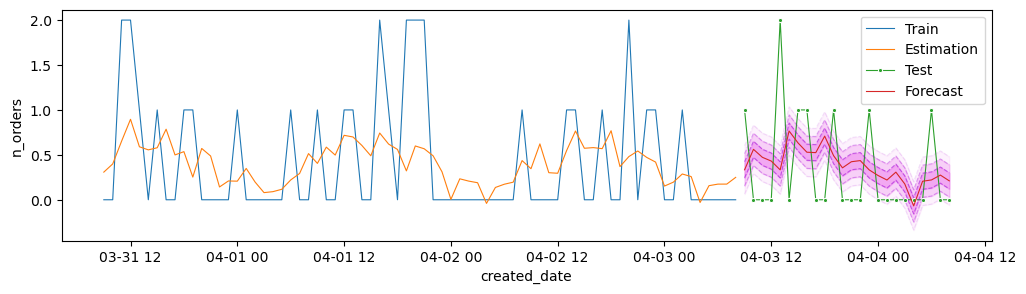

account_id: f9129295-bb08-4330-b60c-9f0beadda521
sales_channel_id: 34
price_total_agg


In [ ]:
id_pairs = list(zip(df_filtered['account_id'], df_filtered['sales_channel_id']))
# id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
summary_dict = {}
forecast_dict = {}
for coverage in [n*10**-1 for n in range(1, 10)]:
# for coverage in [0.4]: # DO NOT DELETE!!!
    
    alpha = 1 - coverage
    
    for account_id, sales_channel_id in id_pairs:

        if (account_id, str(sales_channel_id)) in res_forecast:
            continue
        
        print(f'account_id: {account_id}')
        print(f'sales_channel_id: {sales_channel_id}')

        summary_dict[(account_id, sales_channel_id)] = {}
        
        if sales_channel_id == 'ALL':
            cond = (sales['account_id'] == account_id) & \
                   (sales['status'].notna())
        else:
            cond = (sales['account_id'] == account_id) & \
                   (sales['sales_channel_id'] == sales_channel_id) & \
                   (sales['status'].notna())

        df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
        df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
        df_client = df_client.sort_values('created_date').reset_index(drop=True)
        df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

        df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
        df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

        end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
        start_date = end_date - relativedelta(months=LOOKBACK)
        date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
        df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        # oot_date_index = pd.Series(df_oot.index, name='created_date')
        # combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
        # df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

        forecast_dict[account_id] = {} if account_id not in forecast_dict else forecast_dict[account_id]
        forecast_dict[account_id][sales_channel_id] = {}

        for n, col in enumerate(['price_total_agg', 'n_orders']):
            print(col)
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}'] = {}
            
            df = df_client_mod[col]
            
            df.fillna(0, inplace=True)
            
            lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
            df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
            
            # df = df_lag.loc[df_lag.index <= END_DATE].copy()
            df_train = df_lag.loc[df_lag.index < START_DATE].copy()
            df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
            # df_oot = df_lag.loc[df_lag.index > END_DATE].copy()

            # X, y = df.iloc[:, 1:], df.iloc[:, 0]
            X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
            X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
            # X_oot = df_oot.iloc[:, 1:]
            
            mad = np.mean(np.abs(y_train - y_train.mean()))
            
            model = pm.auto_arima(y_train, seasonal=True, m=24, X=X_train, frequency=24, random_state=42)
            
            p, d, q = model.order
            P, D, Q, m = model.seasonal_order
            
            estimations = model.predict_in_sample(start=X_train.index[0], end=X_train.index[-1], X=X_train)
            
            train_pred = estimations
            train_mae = mean_absolute_error(y_train, train_pred)
            train_rmse = root_mean_squared_error(y_train, train_pred)

            print(f"train RMSE: {train_rmse:.3f}")
            print(f"train MAE:  {train_mae:.3f}")
            
            # gb_forecast = pd.Series(gb.predict(X_test), index=X_test.index)
            
            # forecast_lower, forecast, forecast_upper = calculate_prediction_intervals(y_test, gb_forecast, confidence_level=coverage, n_bootstrap=300)
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_lower'] = []
            # forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['oot_forecast_upper'] = []
            
            # oot_gscv = GridSearchCV(GradientBoostingRegressor(random_state=42, n_iter_no_change=3),
            #                         param_grid={'max_depth': [1, 2, 4, 8, 16],
            #                                     'subsample': [0.2, 0.4, 0.6, 0.8, 1],
            #                                     'max_features': ['sqrt', 'log2', None]},
            #                         scoring='neg_root_mean_squared_error',
            #                         cv=TimeSeriesSplit(),
            #                         n_jobs=-1,
            #                         verbose=1)
            # oot_gscv.fit(X, y)
            # oot_gb = gscv.best_estimator_
            
            # res_test = model.get_prediction(start=START_DATE, end=END_DATE, exog=X_test).summary_frame(alpha=alpha)
            # forecast_lower = pd.Series(res_test['mean_ci_lower'], X_test.index)
            # forecast = pd.Series(res_test['mean'], X_test.index)
            # forecast_upper = pd.Series(res_test['mean_ci_upper'], X_test.index)
            
            df_forecast = model.predict(n_periods=TEST_SIZE, X=X_test, return_conf_int=True, alpha=alpha, frequency=24)
            forecast = df_forecast[0]
            forecast_lower = pd.Series(df_forecast[1][:, 0], index=X_test.index)
            forecast_upper = pd.Series(df_forecast[1][:, 1], index=X_test.index)
            
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast'] = forecast
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_lower'] = forecast_lower
            forecast_dict[account_id][sales_channel_id][f'dataset_{n}']['forecast_upper'] = forecast_upper
            
            test_pred = forecast
            test_mae = mean_absolute_error(y_test, test_pred)
            test_rmse = root_mean_squared_error(y_test, test_pred)

            print(f"test RMSE: {test_rmse:.3f}")
            print(f"test MAE:  {test_mae:.3f}")
            
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
            summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
            
            plt.figure(figsize=(12, 3))
            sns.lineplot(y_train.iloc[-3*TEST_SIZE:], lw=0.8, label='Train')
            sns.lineplot(estimations.iloc[-3*TEST_SIZE:], lw=0.8, label='Estimation')
            sns.lineplot(y_test, lw=0.8, label='Test', marker='o', markersize=3)
            sns.lineplot(forecast, lw=0.8, label='Forecast')
            sns.lineplot(forecast_lower, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(forecast_upper, c='darkviolet', alpha=0.5, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
            sns.lineplot(3*forecast_lower-2*forecast, c='darkviolet', alpha=0.1, linestyle='--', lw=0.8)
            sns.lineplot(3*forecast_upper-2*forecast, c='darkviolet', alpha=0.1, linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
            # sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
            # sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=forecast_lower,
                             y2=forecast_upper,
                             color='violet',
                             alpha=0.5)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=2*forecast_lower-forecast,
                             y2=2*forecast_upper-forecast,
                             color='violet',
                             alpha=0.3)
            plt.fill_between(x=forecast.index[-TEST_SIZE:],
                             y1=3*forecast_lower-2*forecast,
                             y2=3*forecast_upper-2*forecast,
                             color='violet',
                             alpha=0.1)
            # plt.fill_between(x=oot_forecast.index,
            #                     y1=oot_forecast_lower,
            #                     y2=oot_forecast_upper,
            #                     color='violet',
            #                     alpha=0.5)
            plt.legend()
            plt.savefig(f'plots/sarimax/forecast_{account_id}_{sales_channel_id}_{col}_sarimax.png')
            plt.show();
            
        

        # with open(f'sql/machine_learning/forecast_{account_id}_{sales_channel_id}_ml.sql', 'w') as output_file:
        #     pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        #     pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        #     pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
            
        #     no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        #     no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        #     no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        #     for i in range(len(df_test)):
        #         start_time = df_test.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
        #                     {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
        #             """
        #             )
            
        #     pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        #     pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        #     pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
            
        #     no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        #     no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        #     no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        #     for i in range(len(df_oot)):
        #         start_time = df_oot.index[i]
        #         end_time = start_time + pd.Timedelta(hours=1)
        #         output_file.write(
        #             f"""
        #             INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
        #                                   channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                   model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #             VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
        #                     {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'GradientBoosting',
        #                     {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                     {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #             """     
        #             )
                
        pt_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast_upper']
        no_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            start_time = start_time.tz_localize(SAO_PAULO_TZ)
            end_time = end_time.tz_localize(SAO_PAULO_TZ)
            price_insert = \
                f"""
                INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
                                             channel, seller, account_id, organization_id, store_id, minutes_interval,
                                             model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
                        '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'SARIMAX_({p},{d},{q},{P},{D},{Q},{m})_{int(100*coverage)}',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
            cursor.execute(price_insert)
        
        # pt_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_lower']
        # pt_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast_upper']
        # pt_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_0']['oot_forecast']
        
        # no_oot_forecast_lower = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_lower']
        # no_oot_forecast_upper = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast_upper']
        # no_oot_forecast = forecast_dict[account_id][sales_channel_id]['dataset_1']['oot_forecast']
        # for i in range(len(df_oot)):
        #     start_time = df_oot.index[i]
        #     end_time = start_time + pd.Timedelta(hours=1)
        #     start_time = start_time.tz_localize(SAO_PAULO_TZ)
        #     end_time = end_time.tz_localize(SAO_PAULO_TZ)
        #     oot_insert = \
        #         f"""
        #         INSERT INTO public.forecast (id, created, modified, platform, store_name, "start", "end",
        #                                     channel, seller, account_id, organization_id, store_id, minutes_interval,
        #                                     model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
        #         VALUES (gen_random_uuid(), now(), now(), 1, '{account_id}'::uuid, '{start_time}', '{end_time}',
        #                 '{sales_channel_id}', 'ALL', '{account_id}'::uuid, '{account_id}'::uuid, NULL, 60, 'GradientBoosting_{int(100*coverage)}',
        #                 {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
        #                 {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
        #         """
        #     cursor.execute(oot_insert)
            
        cursor.execute('commit;')

In [19]:
forecast

2025-04-03 09:00:00    62054.748732
2025-04-03 10:00:00    74312.558518
2025-04-03 11:00:00    77728.104978
2025-04-03 12:00:00    82915.947905
2025-04-03 13:00:00    93314.427086
2025-04-03 14:00:00    89737.887986
2025-04-03 15:00:00    87271.850904
2025-04-03 16:00:00    71244.913627
2025-04-03 17:00:00    70383.534250
2025-04-03 18:00:00    75490.128617
2025-04-03 19:00:00    87493.221857
2025-04-03 20:00:00    76625.436484
2025-04-03 21:00:00    62917.572133
2025-04-03 22:00:00    64642.324466
2025-04-03 23:00:00    58172.462350
2025-04-04 00:00:00    34070.750061
2025-04-04 01:00:00     3435.382860
2025-04-04 02:00:00    -1358.384841
2025-04-04 03:00:00    -2691.062527
2025-04-04 04:00:00     7769.707628
2025-04-04 05:00:00     8566.853781
2025-04-04 06:00:00     9451.811950
2025-04-04 07:00:00    25036.631667
2025-04-04 08:00:00    43863.486778
Freq: h, dtype: float64

In [ ]:
# cursor.close()